In [1]:
import matplotlib.pyplot as plt
from IPython.display import clear_output
from tqdm import tqdm

import torch
from torch.utils.data import DataLoader

from models.advanced_deature_encoder import (
    MAEResNet, 
    FeatureExtractor, 
    patchify,
    unpatchify
)
from pokemon_dataset import PokemonDataset
from utils import show_batch_grid, get_number_of_parameters

import os

In [2]:
DEVICE = "cuda:0"
IMG_SIZE = 128

dataset_path = "/home/msst/repo/drifting/data/CelebA"
dataset_type = "FACES"

pokemon_dataset = PokemonDataset(root_dir=dataset_path, img_size=IMG_SIZE, dataset_type=dataset_type)

Number of images: 202599


In [3]:
mae_resnet = MAEResNet(
        in_channels = 3,
        base_channels = 256,
        mask_patch_size = 2,
        input_patch_size = 8,
        layers = (3, 4, 6, 3), # ResNet50
    ).to(torch.bfloat16).cuda()

print("mae_resnet:")
get_number_of_parameters(mae_resnet)
get_number_of_parameters(mae_resnet.encoder)
get_number_of_parameters(mae_resnet.decoder)

opt = torch.optim.AdamW(
    mae_resnet.parameters(), 
    lr=2e-4, 
    betas=(0.9, 0.95),
    weight_decay=0.02,
)

mae_resnet:
Params: 430M
Params: 341M
Params: 89.1M


In [4]:
batch_size = 64
dataloader = DataLoader(pokemon_dataset, batch_size=batch_size, shuffle=True, num_workers=8)

In [5]:
test_imgs = next(iter(dataloader))[:8].cuda()

In [9]:
mae_feats = mae_resnet.get_activations(
            test_imgs,
            patch_mean_size=[2, 4],
            patch_std_size=[2, 4],
            use_std=True,
            use_mean=True,
            every_k_block=2,
        )

In [19]:
mae_feats_list = list(mae_feats.values())
len(mae_feats_list)

81

In [16]:
for f in mae_feats.values():
    print(f.shape)

torch.Size([8, 1, 192])
torch.Size([8, 256, 256])
torch.Size([8, 1, 256])
torch.Size([8, 1, 256])
torch.Size([8, 64, 256])
torch.Size([8, 16, 256])
torch.Size([8, 64, 256])
torch.Size([8, 16, 256])
torch.Size([8, 256, 256])
torch.Size([8, 1, 256])
torch.Size([8, 1, 256])
torch.Size([8, 64, 256])
torch.Size([8, 16, 256])
torch.Size([8, 64, 256])
torch.Size([8, 16, 256])
torch.Size([8, 64, 512])
torch.Size([8, 1, 512])
torch.Size([8, 1, 512])
torch.Size([8, 16, 512])
torch.Size([8, 4, 512])
torch.Size([8, 16, 512])
torch.Size([8, 4, 512])
torch.Size([8, 16, 1024])
torch.Size([8, 1, 1024])
torch.Size([8, 1, 1024])
torch.Size([8, 4, 1024])
torch.Size([8, 1, 1024])
torch.Size([8, 4, 1024])
torch.Size([8, 1, 1024])
torch.Size([8, 4, 2048])
torch.Size([8, 1, 2048])
torch.Size([8, 1, 2048])
torch.Size([8, 1, 2048])
torch.Size([8, 1, 2048])
torch.Size([8, 256, 256])
torch.Size([8, 1, 256])
torch.Size([8, 1, 256])
torch.Size([8, 64, 256])
torch.Size([8, 16, 256])
torch.Size([8, 64, 256])
torch.S

In [4]:
batch_size = 512
dataloader = DataLoader(pokemon_dataset, batch_size=batch_size, shuffle=True, num_workers=8)

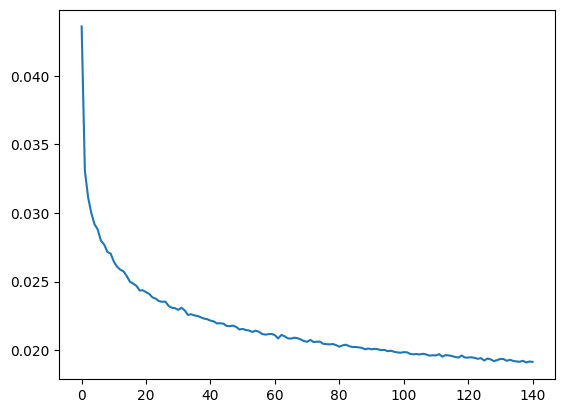

 36%|███▌      | 141/396 [01:47<03:14,  1.31it/s]


KeyboardInterrupt: 

In [7]:
n_epochs = 100
plot_every = 100
save_step = 2500
save_path = "/home/msst/repo/drifting/checkpoints/MAE/CelebA"


steps_per_epoch = len(dataloader)

loss_history = []
plot_loss_acc = []
for e in range(n_epochs):
    for step, batch in enumerate(tqdm(dataloader)):
        global_step = e * steps_per_epoch + step + 1
        
        batch = batch.cuda()
        loss = mae_resnet(batch)[0]
        loss.backward()
        opt.step()
        opt.zero_grad()
        plot_loss_acc.append(loss.item())
        
        if (global_step % plot_every == 0) or (global_step == 5):
            loss_history.append(sum(plot_loss_acc) / len(plot_loss_acc))
            plot_loss_acc = []
            clear_output(wait=True)
            plt.plot(loss_history)
            plt.show()

    # if (global_step+1) % save_step == 0:
    os.makedirs(save_path, exist_ok=True)
    torch.save(mae_resnet.state_dict(), f"{save_path}/transformer_{e}epochs.pth")


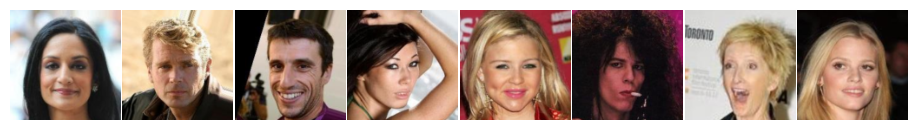

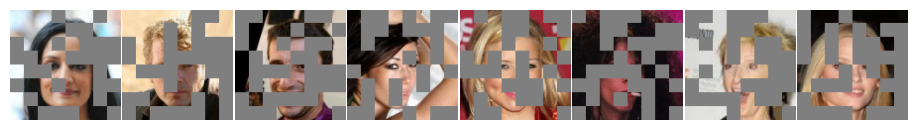

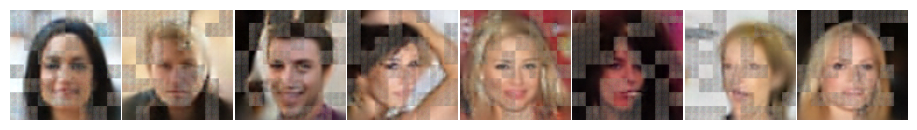

In [8]:
test_imgs = next(iter(dataloader))[:8].cuda()
show_batch_grid(test_imgs, n=8, figsize=(9, 9), denormalize=True)

test_imgs_patched = patchify(test_imgs, patch_size=8)
mask = mae_resnet.make_patch_mask(test_imgs_patched, 0.5, 2)
test_imgs_patched_masked = test_imgs_patched * (1.0 - mask)
test_imgs_masked = unpatchify(test_imgs_patched_masked, patch_size=8, original_channels=3)
show_batch_grid(test_imgs_masked, n=8, figsize=(9, 9), denormalize=True)

feats = mae_resnet.encoder(test_imgs_patched_masked)
recon = mae_resnet.decoder(feats)
recon = unpatchify(recon, patch_size=8, original_channels=3)
show_batch_grid(recon, n=8, figsize=(9, 9), denormalize=True)